In [2]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer, WordNetLemmatizer
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
from sklearn.pipeline import Pipeline
import warnings
warnings.filterwarnings('ignore')


nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('punkt')


df = pd.read_csv('spam.csv', encoding='latin-1')


print("Dataset Shape:", df.shape)
print("\nFirst 5 rows:")
print(df.head())


print("\nColumn names:")
print(df.columns.tolist())


df = df.iloc[:, :2]
df.columns = ['label', 'message']

print("\nCleaned dataset shape:", df.shape)
print(df.head())

Dataset Shape: (5572, 5)

First 5 rows:
     v1                                                 v2 Unnamed: 2  \
0   ham  Go until jurong point, crazy.. Available only ...        NaN   
1   ham                      Ok lar... Joking wif u oni...        NaN   
2  spam  Free entry in 2 a wkly comp to win FA Cup fina...        NaN   
3   ham  U dun say so early hor... U c already then say...        NaN   
4   ham  Nah I don't think he goes to usf, he lives aro...        NaN   

  Unnamed: 3 Unnamed: 4  
0        NaN        NaN  
1        NaN        NaN  
2        NaN        NaN  
3        NaN        NaN  
4        NaN        NaN  

Column names:
['v1', 'v2', 'Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4']

Cleaned dataset shape: (5572, 2)
  label                                            message
0   ham  Go until jurong point, crazy.. Available only ...
1   ham                      Ok lar... Joking wif u oni...
2  spam  Free entry in 2 a wkly comp to win FA Cup fina...
3   ham  U dun say so ear

[nltk_data] Downloading package stopwords to C:\Users\PM
[nltk_data]     COMPUTER\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to C:\Users\PM
[nltk_data]     COMPUTER\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt to C:\Users\PM
[nltk_data]     COMPUTER\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


Missing values:
label      0
message    0
dtype: int64

Class distribution:
label
ham     4825
spam     747
Name: count, dtype: int64

Percentage of spam: 13.41%


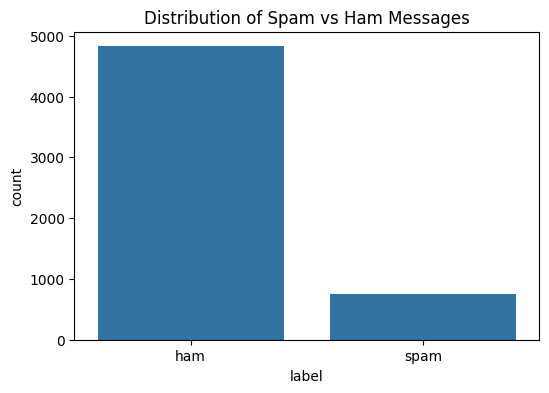

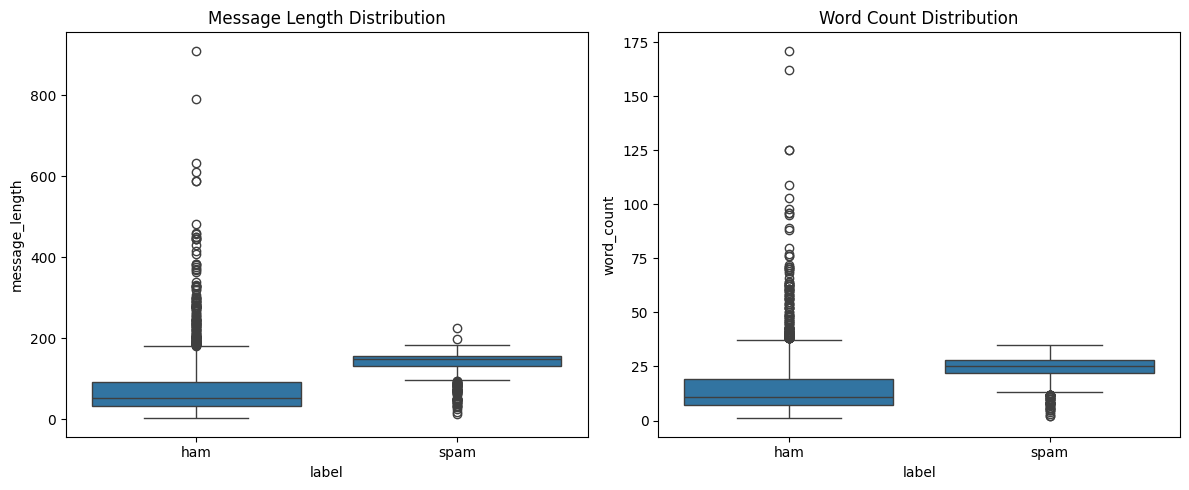


Average message length by class:
label
ham      71.023627
spam    138.866131
Name: message_length, dtype: float64

Average word count by class:
label
ham     14.200622
spam    23.851406
Name: word_count, dtype: float64


In [3]:

print("Missing values:")
print(df.isnull().sum())


print("\nClass distribution:")
print(df['label'].value_counts())
print(f"\nPercentage of spam: {df['label'].value_counts(normalize=True)[1]*100:.2f}%")


plt.figure(figsize=(6, 4))
sns.countplot(x='label', data=df)
plt.title('Distribution of Spam vs Ham Messages')
plt.show()


df['label_num'] = df['label'].map({'ham': 0, 'spam': 1})


df['message_length'] = df['message'].apply(len)
df['word_count'] = df['message'].apply(lambda x: len(x.split()))


plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.boxplot(x='label', y='message_length', data=df)
plt.title('Message Length Distribution')

plt.subplot(1, 2, 2)
sns.boxplot(x='label', y='word_count', data=df)
plt.title('Word Count Distribution')

plt.tight_layout()
plt.show()

print("\nAverage message length by class:")
print(df.groupby('label')['message_length'].mean())
print("\nAverage word count by class:")
print(df.groupby('label')['word_count'].mean())

In [4]:

stemmer = PorterStemmer()
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

def clean_text(text, use_stemming=False, use_lemmatization=True):
    """
    Clean and preprocess text data
    """
    text = text.lower()
    
    text = re.sub(r'[^a-zA-Z0-9\s]', '', text)
    
   
    text = re.sub(r'\d+', '', text)
    
   
    text = re.sub(r'\s+', ' ', text).strip()
    
  
    words = text.split()
    
  
    words = [word for word in words if word not in stop_words]
    
    
    if use_stemming:
        words = [stemmer.stem(word) for word in words]
    elif use_lemmatization:
        words = [lemmatizer.lemmatize(word) for word in words]
    
    return ' '.join(words)


df['clean_message'] = df['message'].apply(clean_text)


print("Original message:")
print(df['message'].iloc[0])
print("\nCleaned message:")
print(df['clean_message'].iloc[0])

Original message:
Go until jurong point, crazy.. Available only in bugis n great world la e buffet... Cine there got amore wat...

Cleaned message:
go jurong point crazy available bugis n great world la e buffet cine got amore wat


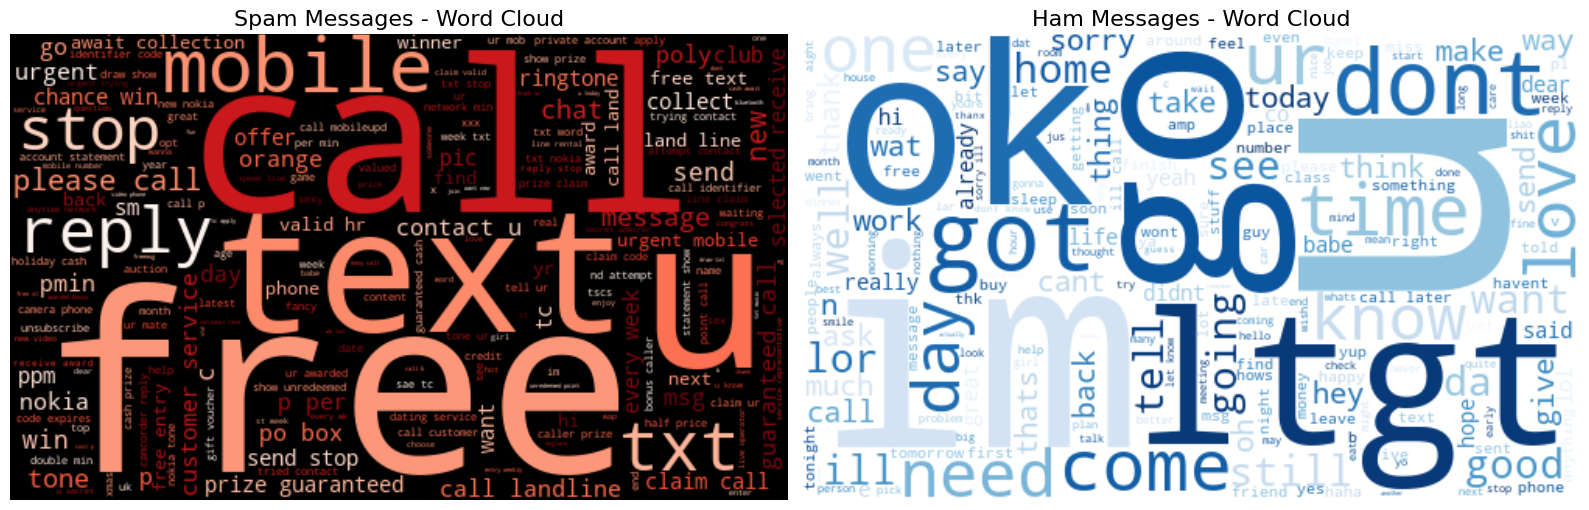

Top 20 words in spam messages:
  call: 362
  free: 219
  u: 163
  txt: 151
  ur: 144
  text: 138
  mobile: 136
  stop: 116
  claim: 115
  reply: 103

Top 20 words in ham messages:
  u: 1043
  im: 461
  get: 318
  ltgt: 276
  go: 275
  ok: 272
  dont: 268
  come: 242
  know: 241
  call: 241


In [5]:

from wordcloud import WordCloud


spam_messages = ' '.join(df[df['label'] == 'spam']['clean_message'])
ham_messages = ' '.join(df[df['label'] == 'ham']['clean_message'])

plt.figure(figsize=(16, 6))


plt.subplot(1, 2, 1)
wordcloud_spam = WordCloud(width=500, height=300, background_color='black', colormap='Reds').generate(spam_messages)
plt.imshow(wordcloud_spam, interpolation='bilinear')
plt.title('Spam Messages - Word Cloud', fontsize=16)
plt.axis('off')


plt.subplot(1, 2, 2)
wordcloud_ham = WordCloud(width=500, height=300, background_color='white', colormap='Blues').generate(ham_messages)
plt.imshow(wordcloud_ham, interpolation='bilinear')
plt.title('Ham Messages - Word Cloud', fontsize=16)
plt.axis('off')

plt.tight_layout()
plt.show()


from collections import Counter

def get_top_words(text_series, n=20):
    all_words = ' '.join(text_series).split()
    return Counter(all_words).most_common(n)

top_spam = get_top_words(df[df['label'] == 'spam']['clean_message'])
top_ham = get_top_words(df[df['label'] == 'ham']['clean_message'])

print("Top 20 words in spam messages:")
for word, count in top_spam[:10]:
    print(f"  {word}: {count}")

print("\nTop 20 words in ham messages:")
for word, count in top_ham[:10]:
    print(f"  {word}: {count}")

In [6]:

df['contains_urgent'] = df['message'].str.contains('urgent|urg|asap', case=False, na=False).astype(int)
df['contains_winner'] = df['message'].str.contains('won|winner|win|claim|prize|cash', case=False, na=False).astype(int)
df['contains_free'] = df['message'].str.contains('free|complimentary', case=False, na=False).astype(int)
df['contains_call'] = df['message'].str.contains('call|text|reply', case=False, na=False).astype(int)
df['contains_money'] = df['message'].str.contains('\$|£|€|pound|dollar', case=False, na=False).astype(int)
df['contains_number'] = df['message'].str.contains('\d', case=False, na=False).astype(int)
df['exclamation_count'] = df['message'].str.count('!')
df['question_count'] = df['message'].str.count('\?')
df['capital_ratio'] = df['message'].apply(lambda x: sum(1 for c in x if c.isupper()) / (len(x) + 1))

print("Feature statistics by class:")
print(df.groupby('label')[['contains_urgent', 'contains_winner', 'contains_free', 
                           'contains_call', 'contains_money', 'exclamation_count']].mean())

Feature statistics by class:
       contains_urgent  contains_winner  contains_free  contains_call  \
label                                                                   
ham           0.004767         0.034404       0.013679       0.084145   
spam          0.085676         0.362784       0.282463       0.670683   

       contains_money  exclamation_count  
label                                     
ham          0.006218           0.173886  
spam         0.374833           0.725569  


In [7]:

X_text = df['clean_message']
X_features = df[['contains_urgent', 'contains_winner', 'contains_free', 
                 'contains_call', 'contains_money', 'contains_number',
                 'exclamation_count', 'question_count', 'capital_ratio']]
y = df['label_num']


X_train_text, X_test_text, X_train_features, X_test_features, y_train, y_test = train_test_split(
    X_text, X_features, y, test_size=0.2, random_state=42, stratify=y)

print(f"Training set size: {len(X_train_text)}")
print(f"Test set size: {len(X_test_text)}")
print(f"\nTraining set distribution:")
print(y_train.value_counts(normalize=True))
print(f"\nTest set distribution:")
print(y_test.value_counts(normalize=True))

Training set size: 4457
Test set size: 1115

Training set distribution:
label_num
0    0.865829
1    0.134171
Name: proportion, dtype: float64

Test set distribution:
label_num
0    0.866368
1    0.133632
Name: proportion, dtype: float64


In [8]:
# TF-IDF Vectorization
tfidf_vectorizer = TfidfVectorizer(max_features=5000, ngram_range=(1, 3), 
                                    min_df=2, max_df=0.8, sublinear_tf=True)

X_train_tfidf = tfidf_vectorizer.fit_transform(X_train_text)
X_test_tfidf = tfidf_vectorizer.transform(X_test_text)

print(f"TF-IDF matrix shape (training): {X_train_tfidf.shape}")
print(f"Number of features: {len(tfidf_vectorizer.get_feature_names_out())}")

# Combine with engineered features
from scipy.sparse import hstack

X_train_combined = hstack([X_train_tfidf, X_train_features.values])
X_test_combined = hstack([X_test_tfidf, X_test_features.values])

print(f"Combined features shape: {X_train_combined.shape}")

TF-IDF matrix shape (training): (4457, 5000)
Number of features: 5000
Combined features shape: (4457, 5009)


In [9]:
results = {}

def evaluate_model(model, X_train, X_test, y_train, y_test, model_name):
   
    model.fit(X_train, y_train)
    
   
    y_pred = model.predict(X_test)
    
   
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    
   
    results[model_name] = {
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1': f1
    }
    
    print(f"\n{model_name} Results:")
    print(f"Accuracy:  {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall:    {recall:.4f}")
    print(f"F1-Score:  {f1:.4f}")
    
  
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=['Ham', 'Spam'], 
                yticklabels=['Ham', 'Spam'])
    plt.title(f'Confusion Matrix - {model_name}')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.show()
    
    return model


Naive Bayes Results:
Accuracy:  0.9812
Precision: 0.9706
Recall:    0.8859
F1-Score:  0.9263


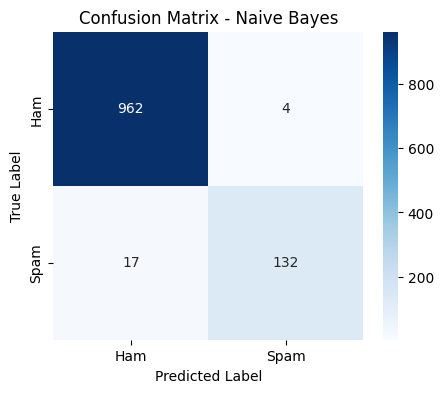

In [10]:

nb_model = MultinomialNB(alpha=0.5)
nb_model = evaluate_model(nb_model, X_train_combined, X_test_combined, 
                          y_train, y_test, "Naive Bayes")


Logistic Regression Results:
Accuracy:  0.9758
Precision: 0.9692
Recall:    0.8456
F1-Score:  0.9032


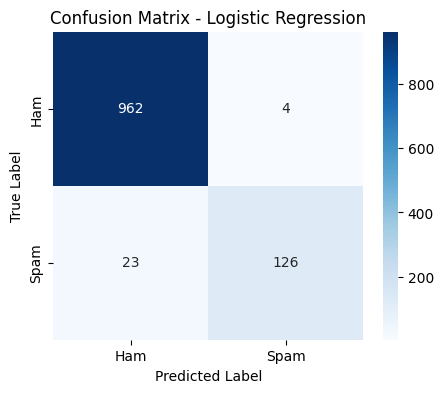

In [11]:

lr_model = LogisticRegression(C=1.0, max_iter=1000, random_state=42)
lr_model = evaluate_model(lr_model, X_train_combined, X_test_combined, 
                          y_train, y_test, "Logistic Regression")


Random Forest Results:
Accuracy:  0.9274
Precision: 1.0000
Recall:    0.4564
F1-Score:  0.6267


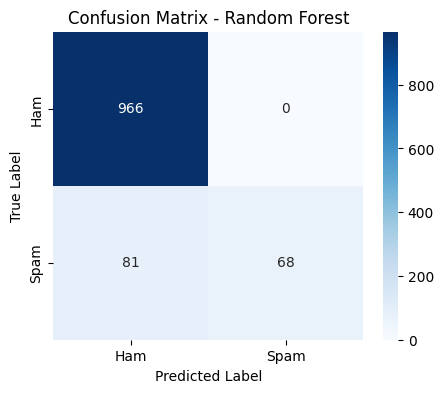

In [12]:

rf_model = RandomForestClassifier(n_estimators=100, max_depth=10, 
                                   random_state=42, n_jobs=-1)
rf_model = evaluate_model(rf_model, X_train_combined, X_test_combined, 
                          y_train, y_test, "Random Forest")


SVM (Linear) Results:
Accuracy:  0.9883
Precision: 0.9789
Recall:    0.9329
F1-Score:  0.9553


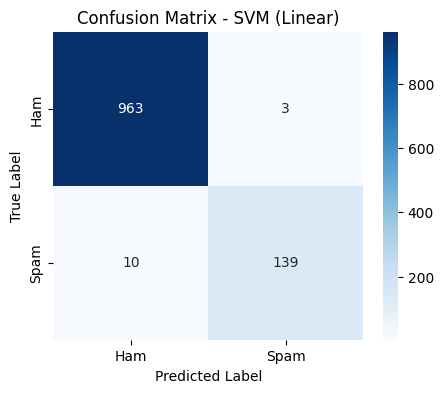

In [13]:

svm_model = SVC(kernel='linear', C=1.0, random_state=42, probability=True)
svm_model = evaluate_model(svm_model, X_train_combined, X_test_combined, 
                           y_train, y_test, "SVM (Linear)")

Model Performance Comparison:
                     accuracy  precision    recall        f1
SVM (Linear)         0.988341   0.978873  0.932886  0.955326
Naive Bayes          0.981166   0.970588  0.885906  0.926316
Logistic Regression  0.975785   0.969231  0.845638  0.903226
Random Forest        0.927354   1.000000  0.456376  0.626728


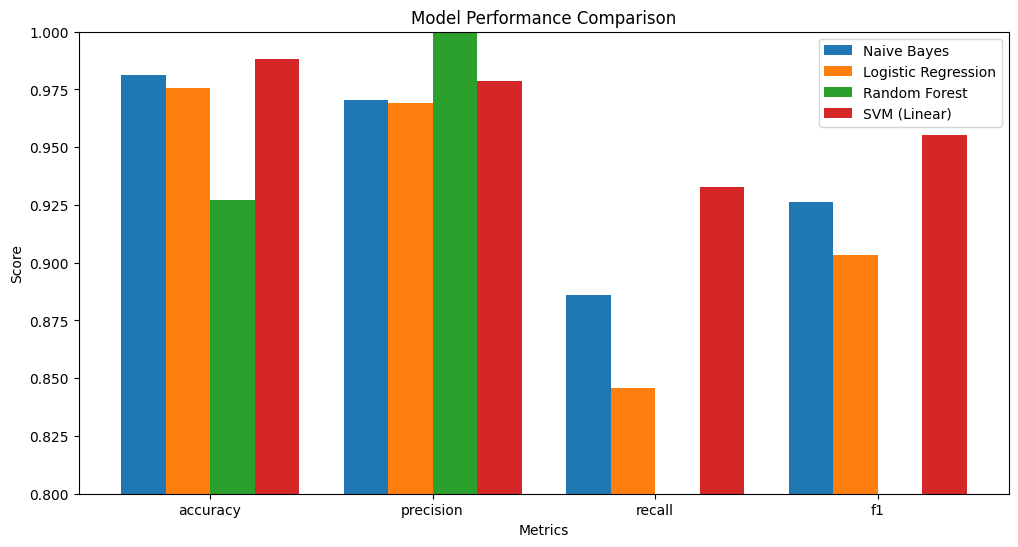


Best Model: SVM (Linear)
Best F1-Score: 0.9553


In [14]:

results_df = pd.DataFrame(results).T
print("Model Performance Comparison:")
print(results_df.sort_values('f1', ascending=False))


plt.figure(figsize=(12, 6))
metrics = ['accuracy', 'precision', 'recall', 'f1']
x = np.arange(len(metrics))
width = 0.2

for i, (model_name, scores) in enumerate(results.items()):
    values = [scores[m] for m in metrics]
    plt.bar(x + i*width, values, width, label=model_name)

plt.xlabel('Metrics')
plt.ylabel('Score')
plt.title('Model Performance Comparison')
plt.xticks(x + width*1.5, metrics)
plt.legend()
plt.ylim(0.8, 1.0)
plt.show()


best_model_name = results_df['f1'].idxmax()
print(f"\nBest Model: {best_model_name}")
print(f"Best F1-Score: {results_df.loc[best_model_name, 'f1']:.4f}")

Using SVM model

Extracting feature importance from linear model...


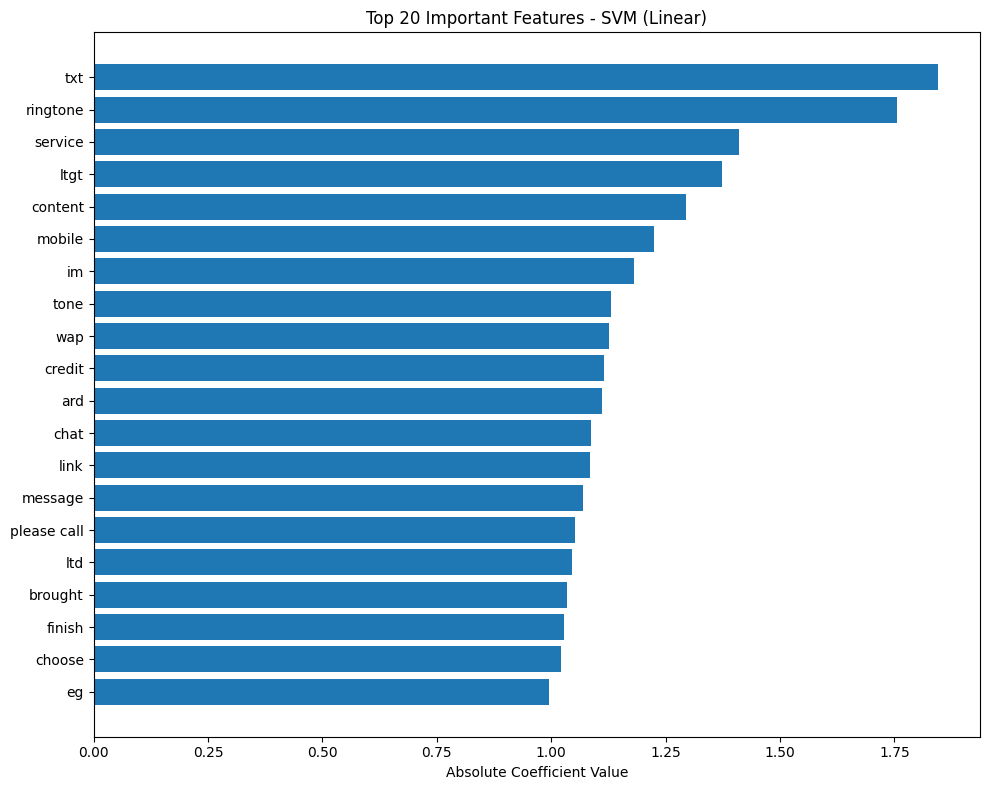


Top 10 most important features for spam detection:
1. txt: 1.8450
2. ringtone: 1.7547
3. service: 1.4101
4. ltgt: 1.3723
5. content: 1.2951
6. mobile: 1.2245
7. im: 1.1807
8. tone: 1.1302
9. wap: 1.1260
10. credit: 1.1162


In [15]:

try:
    best_model_name
except NameError:
   
    if 'results_df' in globals():
        best_model_name = results_df['f1'].idxmax()
        print(f"Best model identified as: {best_model_name}")
    else:
        
        best_model_name = "Logistic Regression"
        print(f"Using default model: {best_model_name}")


if best_model_name == "Logistic Regression" and 'lr_model' in globals():
    model = lr_model
    print("Using Logistic Regression model")
elif best_model_name == "SVM (Linear)" and 'svm_model' in globals():
    model = svm_model
    print("Using SVM model")
elif best_model_name == "Random Forest" and 'rf_model' in globals():
    model = rf_model
    print("Using Random Forest model")
elif best_model_name == "Naive Bayes" and 'nb_model' in globals():
    model = nb_model
    print("Using Naive Bayes model")
else:
    
    if 'pipeline' in globals():
        print("Using pipeline model")
     
        if hasattr(pipeline, 'named_steps'):
            model = pipeline.named_steps['classifier']
        else:
            model = pipeline
    else:
        raise ValueError("No trained model found. Please run Section 8 first.")


if hasattr(model, 'coef_'):
   
    print("\nExtracting feature importance from linear model...")
    
   
    coef = model.coef_
    
   
    if hasattr(coef, 'toarray'):
        feature_importance = np.abs(coef.toarray()).flatten()
    else:
        feature_importance = np.abs(coef).flatten()
    
 
    feature_names = list(tfidf_vectorizer.get_feature_names_out()) + list(X_features.columns)
    
  
    if len(feature_importance) != len(feature_names):
        print(f"Warning: Length mismatch. Adjusting feature names...")
        
        feature_names = list(tfidf_vectorizer.get_feature_names_out())
        feature_importance = feature_importance[:len(feature_names)]
    
  
    n_top = min(20, len(feature_importance))
    top_indices = np.argsort(feature_importance)[-n_top:][::-1]
    
   
    plt.figure(figsize=(10, 8))
    y_pos = np.arange(len(top_indices))
    plt.barh(y_pos, feature_importance[top_indices])
    plt.yticks(y_pos, [feature_names[i] for i in top_indices])
    plt.xlabel('Absolute Coefficient Value')
    plt.title(f'Top {n_top} Important Features - {best_model_name}')
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()
    
    print(f"\nTop {min(10, n_top)} most important features for spam detection:")
    for i, idx in enumerate(top_indices[:min(10, n_top)]):
        print(f"{i+1}. {feature_names[idx]}: {feature_importance[idx]:.4f}")

elif hasattr(model, 'feature_importances_'):
   
    print("\nExtracting feature importance from tree-based model...")
    
    feature_importance = model.feature_importances_
    
  
    feature_names = list(tfidf_vectorizer.get_feature_names_out()) + list(X_features.columns)
    
  
    if len(feature_importance) != len(feature_names):
        print(f"Warning: Length mismatch. Adjusting feature names...")
        # Use only the TF-IDF features
        feature_names = list(tfidf_vectorizer.get_feature_names_out())
        feature_importance = feature_importance[:len(feature_names)]
    
   
    n_top = min(20, len(feature_importance))
    top_indices = np.argsort(feature_importance)[-n_top:][::-1]
    
   
    plt.figure(figsize=(10, 8))
    y_pos = np.arange(len(top_indices))
    plt.barh(y_pos, feature_importance[top_indices])
    plt.yticks(y_pos, [feature_names[i] for i in top_indices])
    plt.xlabel('Feature Importance')
    plt.title(f'Top {n_top} Important Features - {best_model_name}')
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()
    
    print(f"\nTop {min(10, n_top)} most important features for spam detection:")
    for i, idx in enumerate(top_indices[:min(10, n_top)]):
        print(f"{i+1}. {feature_names[idx]}: {feature_importance[idx]:.4f}")

elif best_model_name == "Naive Bayes":
    # For Naive Bayes, we can use feature log probabilities
    print("\nNaive Bayes doesn't provide direct feature importance.")
    print("Showing feature log probabilities instead...")
    
    if hasattr(model, 'feature_log_prob_'):
        # Get the difference between spam and ham log probabilities
        if model.feature_log_prob_.shape[0] == 2:  # Binary classification
            feature_importance = np.abs(model.feature_log_prob_[1] - model.feature_log_prob_[0])
            
            # Get feature names
            feature_names = list(tfidf_vectorizer.get_feature_names_out()) + list(X_features.columns)
            
            # Check if lengths match
            if len(feature_importance) != len(feature_names):
                feature_names = list(tfidf_vectorizer.get_feature_names_out())
                feature_importance = feature_importance[:len(feature_names)]
            
            # Get top features
            n_top = min(20, len(feature_importance))
            top_indices = np.argsort(feature_importance)[-n_top:][::-1]
            
            # Plot
            plt.figure(figsize=(10, 8))
            y_pos = np.arange(len(top_indices))
            plt.barh(y_pos, feature_importance[top_indices])
            plt.yticks(y_pos, [feature_names[i] for i in top_indices])
            plt.xlabel('Absolute Log Probability Difference')
            plt.title(f'Top {n_top} Discriminative Features - Naive Bayes')
            plt.gca().invert_yaxis()
            plt.tight_layout()
            plt.show()
            
            print(f"\nTop {min(10, n_top)} most discriminative features:")
            for i, idx in enumerate(top_indices[:min(10, n_top)]):
                print(f"{i+1}. {feature_names[idx]}: {feature_importance[idx]:.4f}")
    else:
        print("Feature log probabilities not available.")
else:
    print(f"Feature importance extraction not available for {best_model_name}")

Feature columns defined: ['contains_urgent', 'contains_winner', 'contains_free', 'contains_call', 'contains_money', 'contains_number', 'exclamation_count', 'question_count', 'capital_ratio']
Created SVM pipeline
Pipeline dataframe shape: (5572, 10)
Target shape: (5572,)
Training set size: 4457
Test set size: 1115
Pipeline trained successfully!

Pipeline Performance:
Accuracy:  0.9883
Precision: 0.9789
Recall:    0.9329
F1-Score:  0.9553


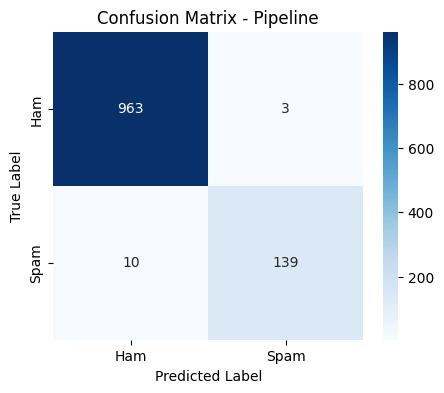

In [16]:

try:
    feature_columns
except NameError:
    
    feature_columns = ['contains_urgent', 'contains_winner', 'contains_free', 
                       'contains_call', 'contains_money', 'contains_number',
                       'exclamation_count', 'question_count', 'capital_ratio']
    print("Feature columns defined:", feature_columns)


from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import FunctionTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_extraction.text import TfidfVectorizer

def create_full_pipeline(model_type='logistic'):
    """
    Create a complete preprocessing and modeling pipeline
    """
   
    def preprocess_text(X):
       
        return [clean_text(text) for text in X]
    
    text_transformer = Pipeline([
        ('clean', FunctionTransformer(preprocess_text, validate=False)),
        ('tfidf', TfidfVectorizer(max_features=5000, ngram_range=(1, 3), 
                                   min_df=2, max_df=0.8, sublinear_tf=True))
    ])
    
   
    feature_columns = ['contains_urgent', 'contains_winner', 'contains_free', 
                       'contains_call', 'contains_money', 'contains_number',
                       'exclamation_count', 'question_count', 'capital_ratio']
    
   
    preprocessor = ColumnTransformer([
        ('text', text_transformer, 'message'),
        ('features', 'passthrough', feature_columns)
    ])
    
   
    if model_type == 'logistic':
        classifier = LogisticRegression(C=1.0, max_iter=1000, random_state=42)
    elif model_type == 'naive_bayes':
        classifier = MultinomialNB(alpha=0.5)
    elif model_type == 'svm':
        classifier = SVC(kernel='linear', C=1.0, random_state=42, probability=True)
    elif model_type == 'random_forest':
        classifier = RandomForestClassifier(n_estimators=100, max_depth=10, 
                                            random_state=42, n_jobs=-1)
    else:
      
        classifier = LogisticRegression(C=1.0, max_iter=1000, random_state=42)
    
  
    pipeline = Pipeline([
        ('preprocessor', preprocessor),
        ('classifier', classifier)
    ])
    
    return pipeline


try:
    best_model_name
except NameError:
  
    best_model_name = "Logistic Regression"
    print(f"Using default model: {best_model_name}")


if best_model_name == "Naive Bayes":
    pipeline = create_full_pipeline('naive_bayes')
    print("Created Naive Bayes pipeline")
elif best_model_name == "Logistic Regression":
    pipeline = create_full_pipeline('logistic')
    print("Created Logistic Regression pipeline")
elif best_model_name == "SVM (Linear)":
    pipeline = create_full_pipeline('svm')
    print("Created SVM pipeline")
elif best_model_name == "Random Forest":
    pipeline = create_full_pipeline('random_forest')
    print("Created Random Forest pipeline")
else:
  
    pipeline = create_full_pipeline('logistic')
    print("Created default Logistic Regression pipeline")


required_columns = ['message'] + feature_columns


missing_columns = [col for col in feature_columns if col not in df.columns]
if missing_columns:
    print(f"Warning: Missing columns: {missing_columns}")
    print("Please run Section 5 to create these features first.")

    for col in missing_columns:
        if col == 'contains_urgent':
            df[col] = df['message'].str.contains('urgent|urg|asap', case=False, na=False).astype(int)
        elif col == 'contains_winner':
            df[col] = df['message'].str.contains('won|winner|win|claim|prize|cash', case=False, na=False).astype(int)
        elif col == 'contains_free':
            df[col] = df['message'].str.contains('free|complimentary', case=False, na=False).astype(int)
        elif col == 'contains_call':
            df[col] = df['message'].str.contains('call|text|reply', case=False, na=False).astype(int)
        elif col == 'contains_money':
            df[col] = df['message'].str.contains('\$|£|€|pound|dollar', case=False, na=False).astype(int)
        elif col == 'contains_number':
            df[col] = df['message'].str.contains('\d', case=False, na=False).astype(int)
        elif col == 'exclamation_count':
            df[col] = df['message'].str.count('!')
        elif col == 'question_count':
            df[col] = df['message'].str.count('\?')
        elif col == 'capital_ratio':
            df[col] = df['message'].apply(lambda x: sum(1 for c in str(x) if c.isupper()) / (len(str(x)) + 1))
    print("Created missing features with default values")


df_pipeline = df[['message'] + feature_columns].copy()
y_pipeline = df['label_num']

print(f"Pipeline dataframe shape: {df_pipeline.shape}")
print(f"Target shape: {y_pipeline.shape}")


from sklearn.model_selection import train_test_split

X_train_pipe, X_test_pipe, y_train_pipe, y_test_pipe = train_test_split(
    df_pipeline, y_pipeline, test_size=0.2, random_state=42, stratify=y_pipeline)

print(f"Training set size: {len(X_train_pipe)}")
print(f"Test set size: {len(X_test_pipe)}")


pipeline.fit(X_train_pipe, y_train_pipe)
print("Pipeline trained successfully!")


y_pred_pipe = pipeline.predict(X_test_pipe)


from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, confusion_matrix

print("\nPipeline Performance:")
print(f"Accuracy:  {accuracy_score(y_test_pipe, y_pred_pipe):.4f}")
print(f"Precision: {precision_score(y_test_pipe, y_pred_pipe):.4f}")
print(f"Recall:    {recall_score(y_test_pipe, y_pred_pipe):.4f}")
print(f"F1-Score:  {f1_score(y_test_pipe, y_pred_pipe):.4f}")


cm = confusion_matrix(y_test_pipe, y_pred_pipe)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Ham', 'Spam'], 
            yticklabels=['Ham', 'Spam'])
plt.title('Confusion Matrix - Pipeline')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

In [17]:
def predict_message(message, pipeline, feature_columns):
    """
    Predict whether a message is spam or ham
    """
   
    data = {'message': [message]}
    
    # Calculate engineered features
    data['contains_urgent'] = [1 if re.search(r'urgent|urg|asap', message, re.I) else 0]
    data['contains_winner'] = [1 if re.search(r'won|winner|win|claim|prize|cash', message, re.I) else 0]
    data['contains_free'] = [1 if re.search(r'free|complimentary', message, re.I) else 0]
    data['contains_call'] = [1 if re.search(r'call|text|reply', message, re.I) else 0]
    data['contains_money'] = [1 if re.search(r'\$|£|€|pound|dollar', message, re.I) else 0]
    data['contains_number'] = [1 if re.search(r'\d', message) else 0]
    data['exclamation_count'] = [message.count('!')]
    data['question_count'] = [message.count('?')]
    data['capital_ratio'] = [sum(1 for c in message if c.isupper()) / (len(message) + 1)]
    
    input_df = pd.DataFrame(data)
    
  
    prediction = pipeline.predict(input_df)[0]
    probability = pipeline.predict_proba(input_df)[0]
    
    result = "SPAM" if prediction == 1 else "HAM"
    confidence = probability[prediction]
    
    print(f"Message: {message}")
    print(f"Prediction: {result}")
    print(f"Confidence: {confidence:.4f}")
    print(f"Spam Probability: {probability[1]:.4f}")
    print("-" * 50)
    
    return prediction, probability


test_messages = [
    "Congratulations! You've won a $1000 gift card. Call now to claim!",
    "Hey, are we still meeting for lunch tomorrow?",
    "URGENT! Your account has been compromised. Please verify immediately.",
    "FREE entry to win a holiday to Bahamas! Text WIN to 87121 now.",
    "I'll be home around 6, can you pick up some milk?",
    "You have been selected to receive a £500 prize. Call 09061701461.",
]

for msg in test_messages:
    predict_message(msg, pipeline, feature_columns)

Message: Congratulations! You've won a $1000 gift card. Call now to claim!
Prediction: SPAM
Confidence: 1.0000
Spam Probability: 1.0000
--------------------------------------------------
Message: Hey, are we still meeting for lunch tomorrow?
Prediction: HAM
Confidence: 0.9999
Spam Probability: 0.0001
--------------------------------------------------
Message: URGENT! Your account has been compromised. Please verify immediately.
Prediction: HAM
Confidence: 0.9814
Spam Probability: 0.0186
--------------------------------------------------
Message: FREE entry to win a holiday to Bahamas! Text WIN to 87121 now.
Prediction: SPAM
Confidence: 1.0000
Spam Probability: 1.0000
--------------------------------------------------
Message: I'll be home around 6, can you pick up some milk?
Prediction: HAM
Confidence: 0.9973
Spam Probability: 0.0027
--------------------------------------------------
Message: You have been selected to receive a £500 prize. Call 09061701461.
Prediction: SPAM
Confidence:

In [18]:

y_pred_best = None
if best_model_name == "Naive Bayes":
    y_pred_best = nb_model.predict(X_test_combined)
elif best_model_name == "Logistic Regression":
    y_pred_best = lr_model.predict(X_test_combined)
elif best_model_name == "Random Forest":
    y_pred_best = rf_model.predict(X_test_combined)
else:
    y_pred_best = svm_model.predict(X_test_combined)


misclassified = np.where(y_pred_best != y_test)[0]

print(f"Total misclassified: {len(misclassified)} out of {len(y_test)}")
print(f"Misclassification rate: {len(misclassified)/len(y_test):.4f}")


false_positives = []  
false_negatives = []  

for idx in misclassified:
    if y_pred_best[idx] == 1 and y_test.iloc[idx] == 0:
        false_positives.append(idx)
    else:
        false_negatives.append(idx)

print(f"\nFalse Positives: {len(false_positives)}")
print(f"False Negatives: {len(false_negatives)}")


print("\nExamples of False Positives (Predicted SPAM, actually HAM):")
for i, idx in enumerate(false_positives[:3]):
    print(f"{i+1}. {df['message'].iloc[X_test_text.index[idx]]}")

print("\nExamples of False Negatives (Predicted HAM, actually SPAM):")
for i, idx in enumerate(false_negatives[:3]):
    print(f"{i+1}. {df['message'].iloc[X_test_text.index[idx]]}")

Total misclassified: 13 out of 1115
Misclassification rate: 0.0117

False Positives: 3
False Negatives: 10

Examples of False Positives (Predicted SPAM, actually HAM):
1. Hey pple...$700 or $900 for 5 nights...Excellent location wif breakfast hamper!!!
2. Hi this is yijue... It's regarding the 3230 textbook it's intro to algorithms second edition... I'm selling it for $50...
3. I guess it is useless calling u 4 something important.

Examples of False Negatives (Predicted HAM, actually SPAM):
1. You are now unsubscribed all services. Get tons of sexy babes or hunks straight to your phone! go to http://gotbabes.co.uk. No subscriptions.
2. ringtoneking 84484
3. Sorry I missed your call let's talk when you have the time. I'm on 07090201529


In [19]:
import joblib


if best_model_name == "Naive Bayes":
    joblib.dump(nb_model, 'spam_classifier_nb.pkl')
elif best_model_name == "Logistic Regression":
    joblib.dump(lr_model, 'spam_classifier_lr.pkl')
elif best_model_name == "Random Forest":
    joblib.dump(rf_model, 'spam_classifier_rf.pkl')
else:
    joblib.dump(svm_model, 'spam_classifier_svm.pkl')


joblib.dump(tfidf_vectorizer, 'tfidf_vectorizer.pkl')
joblib.dump(feature_columns, 'feature_columns.pkl')

print("Model and vectorizer saved successfully!")


joblib.dump(pipeline, 'spam_classifier_pipeline.pkl')
print("Pipeline saved successfully!")

Model and vectorizer saved successfully!


PicklingError: Can't pickle <function create_full_pipeline.<locals>.preprocess_text at 0x00000222E7D69120>: it's not found as __main__.create_full_pipeline.<locals>.preprocess_text